# 実行例5.2 ETL1手書き数字データベースのk最近傍法（kNN法）による識別（p.59図5.9(a)）

- パッケージ類と関数は`5.1_etl1-normalNN.ipynb`流用。
- 型の違いによるエラーを防ぐため、下記のルールを適用。

|<center>用途</center>|<center>使う型</center>|
|---|---|
|バイナリ由来のデータ（structフィールド）|UInt8, UInt16|
|件数・インデックス・kの値|Int|
|距離計算の中間値|Int（Int.(UInt8) で変換）|

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie
using Images
using Colors
using ImageView
using StringEncodings
using ImageFiltering
using ImageTransformations
using Interpolations
using StatsBase
using CUDA

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 0. 関数類
- コード中の括弧書き数字はコピー元（`5.1_etl1-normalNN.ipynb`）のママ

#### 0.1 切り抜き
- `mat`での切り抜きのみ流用

In [2]:
# 閾値調整
threshold_mat = 96

# (2)オリジナル状態での手書き部分の切り抜き（正方形）
function img_cutting_mat(mat::Matrix{UInt8})
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = threshold_mat
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if mat[i, j] > p_threshold
                if i < p_top
                    p_top = i
                end
                if i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                end
                if j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(mat)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(UInt8(0), new_h, new_w)   # オリジナル状態でパディング
    padded[1:h, 1:w] = mat

    # ④正方形に切り抜き
    # cutting_mat = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]
    row_start = max(1, p_top - shift_hight)
    row_end   = min(new_h, row_start + square_cut)
    col_start = max(1, p_left - shift_width)
    col_end   = min(new_w, col_start + square_cut)
    cutting_mat = padded[row_start:row_end, col_start:col_end]

    return cutting_mat, square    # 切り抜き結果の画像、画像の辺の長さ
end

img_cutting_mat (generic function with 1 method)

#### 0.2 フィルタリング
- ガウシアンフィルターのみ流用

In [3]:
# (1) ガウシアンフィルター
# ガウシアンカーネル
function gaussian_kernel(size, sigma)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            k[i, j] = exp(-(x^2 + y^2) / (2 * sigma^2))
        end
    end
    k ./= sum(k)
    return k
end

# ガウシアンフィルター
function gaussian_filter(img, kernel_size=5, sigma=1.0)
    k = gaussian_kernel(kernel_size, sigma)
    return imfilter(img, k)
end

gaussian_filter (generic function with 3 methods)

#### 0.3 リサイズ
- Bicubicでリサイズ

In [4]:
# (1) リサイズ
function img_resize(mat, alg=1)
    #=
    mat⇒
    alg⇒
        1:Bicubic
        2:Bilinear
        3:Nearest neighbor
    =#
    
    if alg == 1
        resized_image = imresize(mat, (16, 16), method=BSpline(Cubic(Line(OnGrid()))))
    elseif alg == 2
        resized_image = imresize(mat, (16, 16), method=BSpline(Linear()))
    elseif alg == 3
        resized_image = imresize(mat, (16, 16), method=BSpline(Constant()))
    else
        resized_image = mat
    end

    return resized_image
end

img_resize (generic function with 2 methods)

#### 0.4 ETL1データの読み込み

In [5]:
# (1)データの定義
struct ETL1normalNN
    data_number::UInt16
    char_code::UInt16
    writer_id::UInt16
    raw_image::Matrix{UInt8}
    test_image::Matrix{UInt8}
end

# (2)ファイルパスの指定
file_01 = joinpath(@__DIR__, "ETL1C_01")
file_02 = joinpath(@__DIR__, "ETL1C_02")

# (3)ファイルの読み込み関数
function read_and_strange(filepath)
    records_normalNN = ETL1normalNN[]
    record_size = 2052
    
    open(filepath, "r") do io
        while !eof(io)
            data = read(io, record_size)
            length(data) < record_size && break
            
            # Metadata
            data_number = ntoh(reinterpret(UInt16, data[1:2])[1])
            char_code   = ntoh(reinterpret(UInt16, data[3:4])[1])
            writer_id   = ntoh(reinterpret(UInt16, data[5:6])[1])
            
            # Image data(raw_image)
            image_data = data[33:2048]
            pixels = UInt8[]
            for byte in image_data
                push!(pixels, (byte >> 4) * 17)
                push!(pixels, (byte & 0x0F) * 17)
            end
            raw_image = transpose(reshape(pixels[1:64*63], 64, 63))

            # Image data(test_image)
            # 切り抜きと位置ズレの補正
            temp_img = img_cutting_mat(Matrix(raw_image))[1]            
            # 画像サイズが十分な場合にフィルターでアンチエリアシング後リサイズ
            # if size(temp_img, 1) == 0
            if size(temp_img, 1) < 5 || size(temp_img, 2) < 5
                temp_img = zeros(UInt8, 16, 16)
            else
                temp_img = gaussian_filter(temp_img, 5, 10)
                temp_img  = img_resize(temp_img, 1) # 1:Bicubic
            end
            test_image = UInt8.(round.(clamp.(temp_img, 0, 255)))

            push!(records_normalNN, ETL1normalNN(
                data_number,
                char_code,
                writer_id,
                raw_image,
                test_image
            ))
        end
    end

    return records_normalNN
end

# (3)ファイルの読み込み
records_normalNN = read_and_strange(file_01)
append!(records_normalNN, read_and_strange(file_02))

# (4)アルファベットデータを除いた数字だけのデータを抽出
records_digits = filter(r -> 0x3020 <= r.char_code <= 0x3920, records_normalNN) # Vector{ETL1normalNN}

14450-element Vector{ETL1normalNN}:
 ETL1normalNN(0x0001, 0x3020, 0x03e9, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x22 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11], UInt8[0x12 0x11 … 0x14 0x16; 0x10 0x11 … 0x15 0x17; … ; 0x11 0x1a … 0x14 0x13; 0x0f 0x11 … 0x13 0x12])
 ETL1normalNN(0x0002, 0x3020, 0x03ea, UInt8[0x11 0x00 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x00], UInt8[0x0e 0x0a … 0x10 0x10; 0x0c 0x0e … 0x0f 0x0f; … ; 0x11 0x0f … 0x0c 0x09; 0x15 0x10 … 0x09 0x0b])
 ETL1normalNN(0x0003, 0x3020, 0x03eb, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x22 … 0x11 0x11], UInt8[0x11 0x10 … 0x12 0x11; 0x11 0x10 … 0x11 0x11; … ; 0x10 0x12 … 0x12 0x13; 0x0f 0x10 … 0x11 0x11])
 ETL1normalNN(0x0004, 0x3020, 0x03ec, UInt8[0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11], UInt8[0x10 0x11 … 0x10 0x0f; 0x0d 0x0f … 0x11 0x10; … ; 0x0e 0x0e … 0x0d 0x0c; 0x0c 0x0c … 

#### 0.5 鋳型との距離
- 第1引数=テストデータ`ETL1normalNN`型（修正）
- 第2引数＝全学習データの`Vector{ETL1normalNN}`型（ママ）

In [6]:
# (1)テストデータと鋳型との距離の計算関数（実際には二乗和の計算）
function distance(x::ETL1normalNN, x_train::Vector{ETL1normalNN})
    distances = [sum((Int.(x.test_image) .- Int.(xi.test_image)).^2) for xi in x_train]

    return distances
end

distance (generic function with 1 method)

#### 0.6 その他の基本処理

In [7]:
# (1)Matrix{UInt8}をグレースケールに変換
function matrix_to_grayscale(img)
    gray_img = Gray{N0f8}.(img ./ 255)
    return gray_img
end

# (2)IntをASCII/ASCIIをIntに変換
function int_to_ascii(n)
    ascii = UInt16((0x30 + n) << 8 | 0x20)
    return ascii
end

function ascii_to_int(ascii::UInt16)
    return Int((ascii >> 8) - 0x30)
end

ascii_to_int (generic function with 1 method)

### 1. kNN法のための関数
- 手順
    1. サンプリング手法によらないkNN法による識別関数を作る。
    2. 一つ抜き法（ジャックナイフ法）もしくはホールドアウト法で分けた`ETL1normalNN`型の全ての鋳型＝学習データ（`records_train`）に対しテストデータ（`records_test`）を識別する。今回は鋳型として全クラスのデータを対象とするので、最近傍法のような数字によるクラスのセット（`data_train`,`data_test`）は作らない。
    3. 識別結果から誤識別件数、誤識別率と後々のために誤識別したデータのインデックスを取得する。

#### 1.1 kNN法での識別関数
- テストデータと距離の近い順に`data_train`のインデックスの配列（`Array`）を準備
- そのため
    1. `distance()`でテストデータに対する全学習データとの距離の` Vector{Int64}`取得（`distance()` : 第1引数=テストデータ`ETL1normalNN`型,　第2引数＝全学習データの`Vector{ETL1normalNN}`型）
    2. 距離が近い順にソートした結果のインデックス準備（`sortperm()` : 値をソートした順番のインデックスを返す関数）
    3. 距離の近い順にk個のインデックスに対応した学習データのクラス（数字の種類）を取り出す。
    4. 取り出したクラスごとにカウントして（`countmap()`）最大値になるクラス（`argmax()`）に識別する。
- `countmap()` : 各要素の出現回数を（要素⇒出現回数）の`Dict`で返す。
- `argmax()` : `Dict`の値（第2要素）を比較してキー（第1要素）を返す。同数の場合はどのキーが返るか不定。kNN法ではkを奇数にするのが一般的な対策になっている。

In [8]:
# (1)kNN識別関数
function kNN_method(x::ETL1normalNN, records_train::Vector{ETL1normalNN}, k::Int64)
    # 第1引数 : テストデータ, 第2引数 : 全学習データ,第3引数 : kNNの鋳型の数
    
    # 全学習データとの距離を計算
    distances = distance(x, records_train)  # Vector{Int64}

    # 距離が小さい順のインデックス
    sorted_idx = sortperm(distances)

    # 上位k件のクラスラベルを整数で取得
    nearest_labels = [ascii_to_int(records_train[sorted_idx[i]].char_code) for i in 1:k]

    # 多数決
    predict = argmax(countmap(nearest_labels))  # Int64

    return predict
end

kNN_method (generic function with 1 method)

#### 1.2 学習/テストデータ分割法ごとに誤識別率を測定（p.13～16）
- ホールドアウト法 : 全データ（`records_digit`）を2分割して、それぞれを学習データとテストデータとする。全データ件数（N件）-学習データ件数（N_train件）がテストデータ件数（N_test件）になる。分割はランダムに行いデータの偏りを防ぐ。
- 一つ抜き法（ジャックナイフ法） : テストデータ以外はすべて学習データとする。全データ（N件）をテストデータとするためN回識別を行う。
- `ETL1normalNN[] ` : `Vector{ETL1normalNN}()`でも同義
- `sample()` : 配列からサンプルをランダムに取り出す関数。例 : `sample(1:10, 3, replace=false)  # 重複なし`
- `shuffle(1:N)` : 今回は使用していない。`sample(1:N, N, replace=false)`と同じ結果が返るので、k番目まで学習データ、残りをテストデータとして使えば良い。
- `setdiff(iterate_A, iterate_B)` : 反復できる要素（イテラブル）同士を比較してAからBを除外して返す。自分で定義した型は`iterate()`を実装しない限り使えない。
- `records_class[i_train]/records_class[i_test]` : 配列のインデックスに配列を渡すと、その要素を集めた新しい配列が返る。
- `append!(array_A, array_B)` : 配列Aに配列Bを結合する。
- `&&` : 短絡評価。左辺の条件が満たされた場合のみ右辺を実行する。`!judge && push!(error_idx, i)`は以下と同義。
```
if judge != true
    error += 1
end
```

In [9]:
# (1)ホールドアウト法によるkNN識別
function kNN_holdout(records::Vector{ETL1normalNN}, C_train::Int64, C_test::Int64, k::Int64)
    # 第1引数 : 全データ, 第2引数 : クラスごとに準備する学習データ件数, 第3引数 : クラスごとに準備するテストデータ, 第4引数 : kNNの鋳型の数
    
    # データ件数
    N = length(records)

    # 学習データとテストデータの配列準備
    records_train = ETL1normalNN[]
    records_test = ETL1normalNN[]
    
    # クラスごとの学習データとテストデータの抽出
    for class in 0:9
        # クラスごとの全データ抽出
        records_class = filter(r -> r.char_code == int_to_ascii(class), records)
        # クラスごとの全データ件数
        N_class = length(records_class)
        # 学習データインデックスの抽出
        i_train = sample(1:N_class, C_train, replace=false)
        # テスト用の残りのデータのインデックス
        # 通常のホールドアウト法
        i_test = sample(setdiff(collect(1:N_class), i_train), C_test, replace=false)
        # 学習データとテストデータ配列へデータ配列追加
        append!(records_train, records_class[i_train])
        append!(records_test, records_class[i_test])
    end


    # 🧊🔽ここからGPU処理を追加
    # 学習・テストデータを行列化してGPUに転送
    train_mat = CuArray(Float32.(hcat([vec(r.test_image) for r in records_train]...)'))  # (N_train, 256)
    test_mat  = CuArray(Float32.(hcat([vec(r.test_image) for r in records_test]...)'))   # (N_test, 256)
    train_labels = [ascii_to_int(r.char_code) for r in records_train]

    # 距離行列を一括計算（N_test × N_train）
    dist_matrix = sum(test_mat.^2, dims=2) .+ sum(train_mat.^2, dims=2)' .- 2 * test_mat * train_mat'
    dist_cpu = Array(dist_matrix)  # CPUに戻す
    # 🧊🔼ここまでGPU処理

    
    # 全学習データでkNN識別実施    
    # 誤識別件数の初期化
    error = 0
    # 誤識別インデックス配列の型宣言
    error_idx = []    
    # テストデータの全件識別
    # # ⚙️🔽CPU処理のママの場合
    # for i in 1:length(records_test)
    #     # x : テストデータ
    #     x = records_test[i]
    #     # 識別
    #     predict = kNN_method(x, records_train, k)
    #     # 判定
    #     judge = Bool(predict == ascii_to_int(x.char_code))        
    #     # エラー件数の追加
    #     !judge && (error += 1)  # 短絡評価&&
    #     # エラーのインデックスを配列に追加
    #     !judge && push!(error_idx, i)
    # end
    # # ⚙️🔼ここまでがCPU処理
    # 🧊🔽GPU処理に変更する場合
    for idx in 1:length(records_test)
        dists = dist_cpu[idx, :]
        sorted_idx = sortperm(dists)
        nearest_labels = [train_labels[sorted_idx[j]] for j in 1:k]
        predict = argmax(countmap(nearest_labels))
        judge = predict == ascii_to_int(records_test[idx].char_code)
        !judge && (error += 1)
        !judge && push!(error_idx, idx)
    end
    # 🧊🔼ここまでGPU処理

    # 誤識別率の計算
    error_rate = error / (C_test * 10)

    return (error, error_rate, error_idx)
end

# (2)一つ抜き法によるkNN識別
function kNN_jackknife(records::Vector{ETL1normalNN}, C_select::Int64, k::Int64)
    # 第1引数 : 全データ, 第2引数 : クラスごとに抽出するデータ件数, 打3引数 : kNNの鋳型の数

    # 学習データ＋テストデータの配列準備
    records_select = ETL1normalNN[]
    
    # クラスごとの学習データ＋テストデータの抽出
    for class in 0:9
        # クラスごとの全データ抽出
        records_class = filter(r -> r.char_code == int_to_ascii(class), records)
        # クラスごとの全データ件数
        N_class = length(records_class)
        # 学習データインデックスの抽出
        i_select = sample(1:N_class, C_select, replace=false)
        # 学習データとテストデータ配列へデータ配列追加
        append!(records_select, records_class[i_select])
    end

    # 🧊🔽GPU処理を追加する場合
    # 全データを行列化してGPUに転送
    all_mat = CuArray(Float32.(hcat([vec(r.test_image) for r in records_select]...)'))  # (N, 256)
    all_labels = [ascii_to_int(r.char_code) for r in records_select]
    # 距離行列を一括計算（N × N）
    dist_matrix = sum(all_mat.^2, dims=2) .+ sum(all_mat.^2, dims=2)' .- 2 * all_mat * all_mat'
    dist_cpu = Array(dist_matrix)
    # 🧊🔼ここまでGPU前処理

    # 全データから1つずつ抜き出し残りのデータとkNN識別実施
    # 誤識別件数の初期化
    error = 0
    # 誤識別インデックス配列の型宣言
    error_idx = []
    # テストデータの全件識別
    # # ⚙️🔽CPU処理のママの場合
    # for i in 1:length(records_select)
    #     # x : テストデータ
    #     x = records_select[i]
    #     # 学習データ
    #     records_train = records_select[setdiff(1:length(records_select), i)]
    #     # 識別
    #     predict = kNN_method(x, records_train, k)
    #     # 判定
    #     judge = Bool(predict == ascii_to_int(x.char_code))
    #     # エラー件数の追加
    #     !judge && (error += 1)  # 短絡評価&&
    #     # エラーのインデックスを配列に追加
    #     !judge && push!(error_idx, i)
    # end
    # # ⚙️🔼ここまでがCPU処理
    # 🧊🔽GPU処理に変更する場合
    for i in 1:length(records_select)
        # i列を除いた距離（自分自身を除外）
        dists = dist_cpu[i, setdiff(1:length(records_select), i)]
        sorted_idx = sortperm(dists)
        nearest_labels = [all_labels[setdiff(1:length(records_select), i)[sorted_idx[j]]] for j in 1:k]
        predict = argmax(countmap(nearest_labels))
        judge = predict == ascii_to_int(records_select[i].char_code)
        !judge && (error += 1)
        !judge && push!(error_idx, i)
    end
    # 🧊🔼ここまでGPU処理

    # 誤識別率の計算
    error_rate = error / (C_select * 10)

    return (error, error_rate, error_idx)
end

kNN_jackknife (generic function with 1 method)

【テスト】各手法による誤識別率

In [10]:
k = 1
# error_rate_holdout = kNN_holdout(records_digits, 650, 650, k)[2]
# error_rate_jackknife = kNN_jackknife(records_digits, 650, k)[2]
# println("ホールドアウト：", round(error_rate_holdout*100, digits=2), "%, ジャックナイフ：", round(error_rate_jackknife*100, digits=2), "%")

1

### 2. kの違いによる誤り率の変化
- kを変化させながら20回試行した場合の誤り率の平均を取得する。

#### 2.1 20回の試行を行い平均を取る
- ホールドアウト法の場合 : ランダムにサンプリングした各クラス650個の学習データと残り650個のテストデータによる計算
- 一つ抜き法の場合 : 各クラス650個のデータを使用した計算
- 関数の戻り値は自動的にタプルになるため`()` がなくても同じ。
- 計算を並列化する。
    1. `Threads.@threads`でCPUのスレッドによる並列計算を行う。
    2. 結果を格納する`Vector`を準備する（並列化で事前に型とサイズを確保する）。`[]`だと型が`Any`でサイズも未確定なので使えない。
    3. `push!`だとスレッドセーフではない（各スレッドで競合する）ので使えない。

In [11]:
# (1)p.60図5.9(a)の条件に合わせた20回の試行の平均
function trial_20times(records::Vector{ETL1normalNN}, k::Int64)
    # 第1引数 : 全データ, 第2引数 : kNNの鋳型の数
    # 20回試行の誤識別率の配列準備
    rate_holdout = Vector{Float64}(undef, 20)
    rate_jackknife = Vector{Float64}(undef, 20)
    Threads.@threads for i in 1:20
        # println("i=$i, thread=$(Threads.threadid())") # 使用スレッドの表示
        # ホールドアウト法              
        rate_holdout[i] = kNN_holdout(records_digits, 650, 650, k)[2]
        #ジャックナイフ法
        rate_jackknife[i] = kNN_jackknife(records_digits, 650, k)[2]
    end

    return (rate_holdout, rate_jackknife)
end

trial_20times (generic function with 1 method)

#### 2.2 kを変化させた時の誤識別率の測定
- kを奇数で取り、多数決で同数を防ぐ。

In [12]:
# (1)kの配列
k = [1, 3, 5, 7, 9, 11, 13, 15]

# (2)kを変化させて誤識別率を測定
cal_time = @time results = [trial_20times(records_digits, i) for i in k]
rate_holdout   = [r[1] for r in results]  # 各kのholdout結果
rate_jackknife = [r[2] for r in results]  # 各kのjackknife結果

println(cal_time)

1066.065933 seconds (259.94 M allocations: 2.362 TiB, 68.42% gc time, 294 lock conflicts, 4.80% compilation time: 2% of which was recompilation)
[([0.05830769230769231, 0.05507692307692308, 0.05353846153846154, 0.055384615384615386, 0.05753846153846154, 0.05430769230769231, 0.05815384615384615, 0.06, 0.06, 0.053384615384615385, 0.060153846153846155, 0.057692307692307696, 0.05923076923076923, 0.056, 0.06092307692307692, 0.05476923076923077, 0.057692307692307696, 0.057846153846153846, 0.06230769230769231, 0.055384615384615386], [0.05723076923076923, 0.05692307692307692, 0.05815384615384615, 0.057076923076923074, 0.06153846153846154, 0.05969230769230769, 0.058923076923076925, 0.05953846153846154, 0.057076923076923074, 0.055846153846153844, 0.055846153846153844, 0.058923076923076925, 0.05753846153846154, 0.05923076923076923, 0.05830769230769231, 0.05369230769230769, 0.05692307692307692, 0.05738461538461539, 0.053384615384615385, 0.060307692307692305]), ([0.05969230769230769, 0.058923076923

#### 2.3 誤識別率の20回平均のプロット

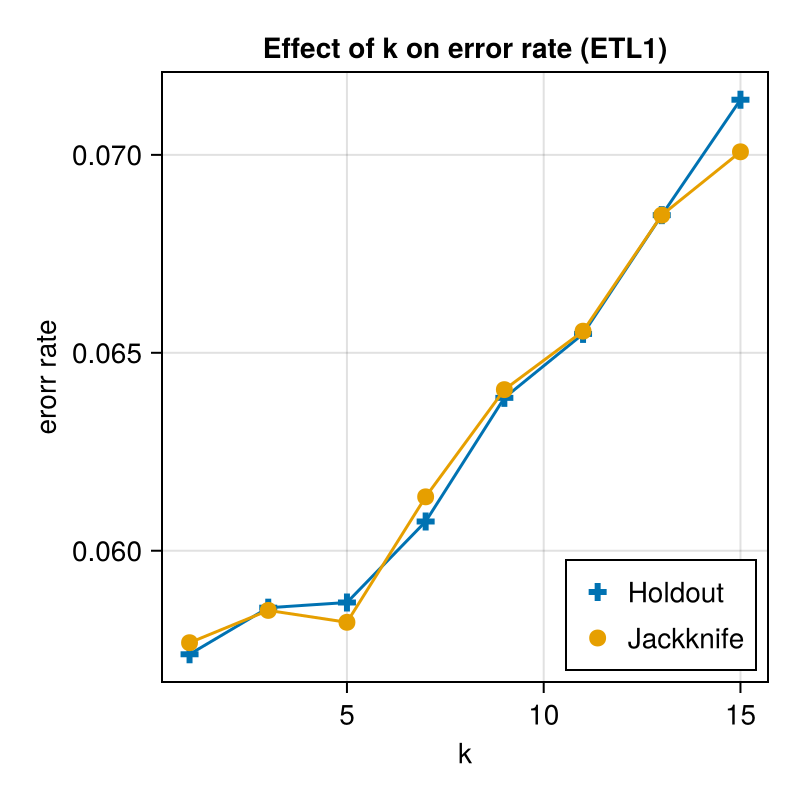

In [13]:
# (1)kごとの20回の誤識別率平均
μ_rate_holdout = [mean(rate_holdout[j]) for j in 1:length(k)]
μ_rate_jackknife = [mean(rate_jackknife[j]) for j in 1:length(k)]

# (2)誤識別率平均のプロット
fig = Figure(size = (400, 400))
ax = CairoMakie.Axis(fig[1, 1],
    xlabel="k",
    ylabel="erorr rate",
    title="Effect of k on error rate (ETL1)")
lines!(ax, k, μ_rate_holdout)
scatter!(ax, k, μ_rate_holdout, marker=:cross, markersize=12, label="Holdout")
lines!(ax, k, μ_rate_jackknife)
scatter!(ax, k, μ_rate_jackknife, marker=:circle, markersize=12, label="Jackknife")
axislegend(ax, position=:rb)

save("etl1_kNN_error_rate.png", fig)
fig